# **Background: Charles Book Club**

Charles Book Club (CBC) is preparing to release a new book titled "The Art History of Florence". CBC has sent a test mailing to a random sample of 4,000 customers from its customer base. The customer responses have been collated with past purchase data. Each row (or case) in the spreadsheet corresponds to one test customer. The variable names and descriptions are given below.

| **VARIABLES**      | **DESCRIPTIONS** |
|--------------------|----------------|
| ID#               | Identification number in the full (unpartitioned) market test data set |
| Gender           | 0 = Male, 1 = Female |
| Amt_Purchased    | Amt_Purchased (Monetary) - Total money spent on books |
| Last_Purchase    | Last_Purchase (Recency) - Months since last purchase |
| Frequency        | Frequency - Total number of purchases |
| First_Purchase   | Months since first purchase |
| ChildBks         | Number of purchases from the category: Child books |
| YouthBks        | Number of purchases from the category: Youth books |
| CookBks         | Number of purchases from the category: Cookbooks |
| DIYBks          | Number of purchases from the category: Do It Yourself books |
| RefBks          | Number of purchases from the category: Reference books (Atlases, Encyclopedias, Dictionaries) |
| ArtBks          | Number of purchases from the category: Art books |
| GeoBks          | Number of purchases from the category: Geography books |
| ItalCook        | Number of purchases of book title: "Secrets of Italian Cooking." |
| ItalAtlas       | Number of purchases of book title: "Historical Atlas of Italy." |
| ItalArt         | Number of purchases of book title: "Italian Art." |
| Florence        | =1 if "The Art History of Florence" was bought, =0 if not |



CBC is considering sending a promotion mail campaign to 10% of its customer base.It is known that they have 1,000,000 customers in the full database. Thus, promotion campaign will cover 100,000 customers. Each promotion mail contains a USD 5 coupon for the purchase of the new book “The Art History of Florence”.  The mailing cost per customer is USD 0.65. The revenue per customer of the purchase of the “The Art History of Florence” is USD 31.95, while the production and overhead cost per book is USD 15. The manager at CBC is interested in understanding the financial gains from a targeted campaign versus a random one.

# **Load libraries and dataset**

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, accuracy_score

In [2]:
# Load the transaction data
df = pd.read_csv('cleaned_book_club.csv')

In [3]:
df

,CustomerID,Gender,Amt_Purchased,Last_Purchase,Frequency,First_Purchase,ChildBks,YouthBks,CookBks,DIYBks,RefBks,ArtBks,GeogBks,ItalCook,ItalAtlas,ItalArt,Florence
0,25,1,297,14,2,22,0,1,1,0,0,0,0,0,0,0,0
1,29,0,128,8,2,10,0,0,0,0,0,0,0,0,0,0,0
2,46,1,138,22,7,56,2,1,2,0,1,0,1,1,0,0,0
3,47,1,228,2,1,2,0,0,0,0,0,0,0,0,0,0,0
4,51,1,257,10,1,10,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,32950,0,141,2,2,6,0,0,0,0,0,0,0,0,0,0,0
3996,32954,1,357,16,9,52,1,1,2,2,2,0,1,0,0,0,0
3997,32955,0,48,12,1,12,0,0,0,0,0,0,0,0,0,0,0
3998,32976,0,214,14,7,38,1,1,3,1,0,0,0,0,0,0,0


## Assignment Instructions

1. **Download the dataset** (cleaned_book_club.csv) and explore the data.

2. **Build a logistic regression model** to predict customer purchases based on the provided variables.  

3. **Use your model to determine the financial gain** of a targeted campaign versus a random campaign.

4. **Work in pairs or individually**




*   Net profit of one purchase = 31.95-15-5=11.95
*   Total cost of mailing: 0.65 * 100,000=65000
*   Financial gain from a targeted promotion vs random mail campain = 11.95*(Response rate from Targeted - Response rate from random) * 100000


So we need to figure out the difference in the response rate through the targeted campaign and the random campaign

# **Response rate from a random campaign?**

In [4]:
# Random campaign response rate
overall_response_rate = df['Florence'].mean()
print(f"Overall Response Rate: {overall_response_rate}")

Overall Response Rate: 0.0845


# **Logistic Regression Model**

## Base Model on RFM

In [5]:
# Create a Logistic Regression Model (Model 1)
mod1 = smf.logit(formula="Florence ~ Last_Purchase + Frequency + Amt_Purchased", data=df).fit()
print(mod1.summary())

Optimization terminated successfully.
         Current function value: 0.284748
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               Florence   No. Observations:                 4000
Model:                          Logit   Df Residuals:                     3996
Method:                           MLE   Df Model:                            3
Date:                Wed, 12 Mar 2025   Pseudo R-squ.:                 0.01684
Time:                        21:54:46   Log-Likelihood:                -1139.0
converged:                       True   LL-Null:                       -1158.5
Covariance Type:            nonrobust   LLR p-value:                 1.724e-08
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -2.2886      0.161    -14.213      0.000      -2.604      -1.973
Last_Purchase    -0.

## Model with additional variables

In [6]:
# Create a Logistic Regression Model (Model 2) with additional predictors
mod2 = smf.logit(formula="Florence ~ Last_Purchase + Frequency + Amt_Purchased + Gender +ChildBks + YouthBks + CookBks + DIYBks + RefBks + ArtBks +GeogBks + ItalCook + ItalAtlas + ItalArt", data=df).fit()
print(mod2.summary())

Optimization terminated successfully.
         Current function value: 0.273320
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               Florence   No. Observations:                 4000
Model:                          Logit   Df Residuals:                     3985
Method:                           MLE   Df Model:                           14
Date:                Wed, 12 Mar 2025   Pseudo R-squ.:                 0.05630
Time:                        21:54:48   Log-Likelihood:                -1093.3
converged:                       True   LL-Null:                       -1158.5
Covariance Type:            nonrobust   LLR p-value:                 5.571e-21
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -2.3938      0.197    -12.147      0.000      -2.780      -2.008
Last_Purchase    -0.

# Sorted Predicted Probabilities

In [7]:
# Predict probabilities using Model 2
df['FlorenceProb'] = mod2.predict(df)
df

,CustomerID,Gender,Amt_Purchased,Last_Purchase,Frequency,First_Purchase,ChildBks,YouthBks,CookBks,DIYBks,RefBks,ArtBks,GeogBks,ItalCook,ItalAtlas,ItalArt,Florence,FlorenceProb
0,25,1,297,14,2,22,0,1,1,0,0,0,0,0,0,0,0,0.035794
1,29,0,128,8,2,10,0,0,0,0,0,0,0,0,0,0,0,0.111698
2,46,1,138,22,7,56,2,1,2,0,1,0,1,1,0,0,0,0.042926
3,47,1,228,2,1,2,0,0,0,0,0,0,0,0,0,0,0,0.060481
4,51,1,257,10,1,10,0,0,0,0,0,0,0,0,0,0,0,0.054267
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,32950,0,141,2,2,6,0,0,0,0,0,0,0,0,0,0,0,0.118622
3996,32954,1,357,16,9,52,1,1,2,2,2,0,1,0,0,0,0,0.045399
3997,32955,0,48,12,1,12,0,0,0,0,0,0,0,0,0,0,0,0.089075
3998,32976,0,214,14,7,38,1,1,3,1,0,0,0,0,0,0,0,0.051162


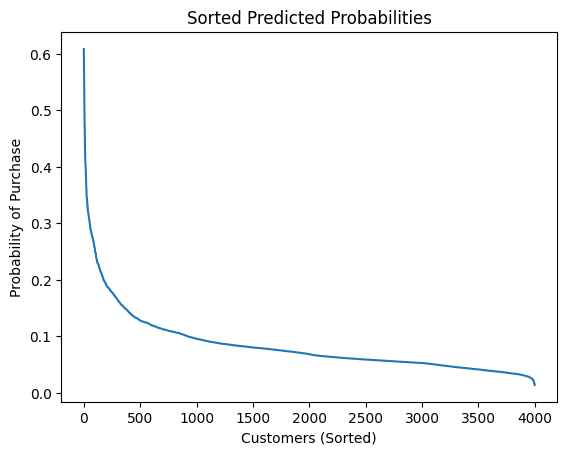

In [8]:
# Plot the sorted probabilities
plt.plot(sorted(df['FlorenceProb'], reverse=True))
plt.title("Sorted Predicted Probabilities")
plt.xlabel("Customers (Sorted)")
plt.ylabel("Probability of Purchase")
plt.show()


This plot visualizes the distribution of purchase probabilities, highlighting the customers most likely to respond (left side of the plot) and least likely to respond (right side).
- The curve starts high and drops sharply, it indicates a few customers have very high probabilities of purchasing.
- A flatter curve suggests the probabilities are more evenly distributed, potentially making targeting less effective.


In [9]:
# Sort the dataframe by predicted probability in descending order
df_sorted = df.sort_values(by="FlorenceProb", ascending=False)
df_sorted

,CustomerID,Gender,Amt_Purchased,Last_Purchase,Frequency,First_Purchase,ChildBks,YouthBks,CookBks,DIYBks,RefBks,ArtBks,GeogBks,ItalCook,ItalAtlas,ItalArt,Florence,FlorenceProb
1256,10541,1,189,4,11,30,0,1,0,0,0,1,1,0,0,1,1,0.608672
1124,9484,0,254,12,9,64,0,2,1,1,0,2,2,1,0,2,1,0.588698
89,723,1,215,2,8,36,0,0,0,0,1,3,2,0,0,0,1,0.576994
846,7079,1,345,20,11,84,1,0,1,0,2,3,4,0,0,0,1,0.549134
753,6495,0,172,14,7,36,0,0,0,0,1,2,3,0,0,0,1,0.537376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1848,15218,1,190,34,7,48,2,0,5,0,0,0,1,0,0,0,0,0.016668
3196,26295,1,155,32,7,74,3,0,4,0,0,0,0,0,0,0,0,0.016617
1217,10207,1,276,32,7,64,1,0,5,0,1,0,0,1,0,0,0,0.015054
353,3072,1,422,18,9,56,3,0,5,1,0,0,0,0,0,0,0,0.014648


# The response rate from the top 10% customers

In [10]:
# Determine the number of customers in the top 10%
top_10_percent_count = int(0.10 * len(df))

# Select the top 10% of customers
top_10_percent = df_sorted.head(top_10_percent_count)

# Calculate the response rate in the top 10%
response_rate_top_10 = top_10_percent["Florence"].mean()

# Display the response rate
print("Response Rate for Top 10% Customers:", response_rate_top_10)


Response Rate for Top 10% Customers: 0.2225


# Financial Benefit from a targeted campaign vs a random one

In [11]:
11.95*(response_rate_top_10 - overall_response_rate) * 100000

164910.0

# ROC Curve and Threshold selection

## Let's start with a threshold of 0.5

In [12]:
# Add a prediction column based on a threshold of 0.5
df['FlorencePred'] = (df['FlorenceProb'] >= 0.5).astype(int)

In [13]:
df

,CustomerID,Gender,Amt_Purchased,Last_Purchase,Frequency,First_Purchase,ChildBks,YouthBks,CookBks,DIYBks,RefBks,ArtBks,GeogBks,ItalCook,ItalAtlas,ItalArt,Florence,FlorenceProb,FlorencePred
0,25,1,297,14,2,22,0,1,1,0,0,0,0,0,0,0,0,0.035794,0
1,29,0,128,8,2,10,0,0,0,0,0,0,0,0,0,0,0,0.111698,0
2,46,1,138,22,7,56,2,1,2,0,1,0,1,1,0,0,0,0.042926,0
3,47,1,228,2,1,2,0,0,0,0,0,0,0,0,0,0,0,0.060481,0
4,51,1,257,10,1,10,0,0,0,0,0,0,0,0,0,0,0,0.054267,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,32950,0,141,2,2,6,0,0,0,0,0,0,0,0,0,0,0,0.118622,0
3996,32954,1,357,16,9,52,1,1,2,2,2,0,1,0,0,0,0,0.045399,0
3997,32955,0,48,12,1,12,0,0,0,0,0,0,0,0,0,0,0,0.089075,0
3998,32976,0,214,14,7,38,1,1,3,1,0,0,0,0,0,0,0,0.051162,0


In [14]:
# Compute confusion matrix
cm = confusion_matrix(df['Florence'], df['FlorencePred'])

# Convert to DataFrame with labels
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])

print("Confusion Matrix:\n", cm_df)

Confusion Matrix:
           Predicted 0  Predicted 1
Actual 0         3662            0
Actual 1          332            6


In [15]:
# Compute the ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(df['Florence'], df['FlorenceProb'])
auc_score = roc_auc_score(df['Florence'], df['FlorenceProb'])
print(f"AUC Score: {auc_score}")

AUC Score: 0.651704778647811


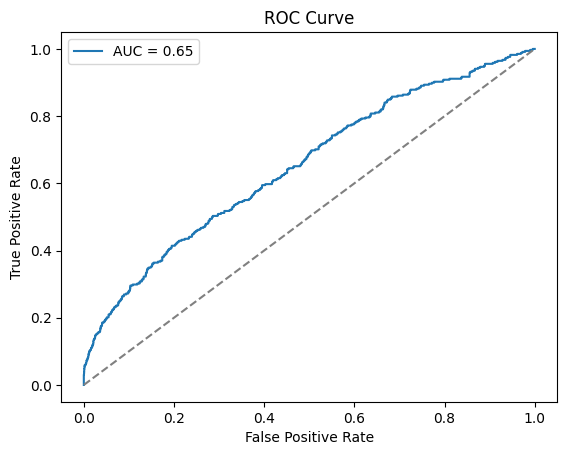

In [16]:
# Plot the ROC Curve
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


### Explanation: ROC Curve and AUC Computation

#### **What the Code Does**

1. **ROC Curve:**
   ```python
   fpr, tpr, thresholds = roc_curve(df['Florence'], df['FlorenceProb'])
   ```
   - **Input Parameters**:
     - `df['Florence']`: The actual labels (1 if the customer purchased "The Art History of Florence," 0 otherwise).
     - `df['FlorenceProb']`: Predicted probabilities from the logistic regression model indicating the likelihood of purchase.
   - **Output**:
     - `fpr` (False Positive Rate): The proportion of negative cases (non-purchasers) that are incorrectly classified as positive (purchasers).
     - `tpr` (True Positive Rate or Sensitivity): The proportion of positive cases (purchasers) correctly classified as positive.
     - `thresholds`: The probability thresholds used to compute `fpr` and `tpr`.

   The ROC curve plots `tpr` vs. `fpr` at various thresholds, showing the trade-off between sensitivity and specificity.

2. **AUC Score:**
   ```python
   auc_score = roc_auc_score(df['Florence'], df['FlorenceProb'])
   ```
   - **AUC (Area Under the Curve)**: A single metric summarizing the performance of the ROC curve.
   - Ranges from 0 to 1:
     - **1.0**: Perfect classifier.
     - **0.5**: No discriminative power (random guessing).
     - **<0.5**: Worse than random guessing.
   - This score indicates how well the model separates positive from negative classes.


#### **Purpose of This Code**
- **ROC Curve**:
  - Visualizes the model's ability to distinguish between purchasers and non-purchasers across various thresholds.
  - Helps identify the optimal trade-off between sensitivity and specificity.
- **AUC Score**:
  - Provides a single measure of the model's classification performance.
  - A higher AUC indicates better predictive performance.

---

#### **Example Interpretation**
- The AUC score is **0.65**, the model has a moderate ability to distinguish purchasers from non-purchasers with 65% accuracy.


## Optimal Threshold

In [17]:
# Find the optimal threshold using the ROC curve
# The threshold is chosen to min the sum of type I and type II
optimal_idx = np.argmin(fpr + (1 - tpr))
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Threshold: {optimal_threshold}")

Optimal Threshold: 0.1049207280545884


In [18]:
# Recalculate predictions using the optimal threshold
df['FlorencePred'] = (df['FlorenceProb'] >= optimal_threshold).astype(int)

# Compute confusion matrix
cm_optimal = confusion_matrix(df['Florence'], df['FlorencePred'])

# Convert to DataFrame for readability
cm_optimal_df = pd.DataFrame(cm_optimal, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])

print("Confusion Matrix (Optimal Threshold):\n", cm_optimal_df)

Confusion Matrix (Optimal Threshold):
           Predicted 0  Predicted 1
Actual 0         2948          714
Actual 1          198          140


the cost of false negative (type II error) is losing profit 11.95, the csot of false positve (type I error) is coupon which is 0.65. so if we are trying to minimize type I error and type II error, it should be minimizing 11.95*fnr + 0.65 * fpr   = 11.95* (1-tpr) + 0.65*fpr

In [19]:
optimal_idx = np.argmin(11.95* (1-tpr)  + 0.65* fpr)  # Maximize TPR + (1 - FPR)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Threshold: {optimal_threshold}")

Optimal Threshold: 0.022929650908827055


In [20]:
# Recalculate predictions using the optimal threshold
df['FlorencePred'] = (df['FlorenceProb'] >= optimal_threshold).astype(int)

# Compute confusion matrix
cm_optimal = confusion_matrix(df['Florence'], df['FlorencePred'])

# Convert to DataFrame for readability
cm_optimal_df = pd.DataFrame(cm_optimal, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])

print("Confusion Matrix (Optimal Threshold):\n", cm_optimal_df)

Confusion Matrix (Optimal Threshold):
           Predicted 0  Predicted 1
Actual 0           16         3646
Actual 1            0          338


# Targeted Campaigns

### Targeted campaign

In [21]:
df['decile'] = pd.qcut(
    df['FlorenceProb'],
    q=10,
    labels=range(1, 11),  # 10 for highest FlorenceProb, 1 for lowest
    duplicates='drop'
)



- **`pd.qcut()`**: This function bins the data into equal-sized quantiles. Since `q=10`, it splits `FlorenceProb` into 10 groups, each containing roughly the same number of observations.
- **`labels=range(1,11)`**: Assigns labels from `1` (lowest probability) to `10` (highest probability). Without labels, `qcut` would return bin intervals instead.
- **`duplicates='drop'`**: If `qcut` detects identical bin edges (e.g., due to many duplicate values), it drops duplicate bins instead of raising an error.


In [22]:
df

,CustomerID,Gender,Amt_Purchased,Last_Purchase,Frequency,First_Purchase,ChildBks,YouthBks,CookBks,DIYBks,RefBks,ArtBks,GeogBks,ItalCook,ItalAtlas,ItalArt,Florence,FlorenceProb,FlorencePred,decile
0,25,1,297,14,2,22,0,1,1,0,0,0,0,0,0,0,0,0.035794,1,1
1,29,0,128,8,2,10,0,0,0,0,0,0,0,0,0,0,0,0.111698,1,9
2,46,1,138,22,7,56,2,1,2,0,1,0,1,1,0,0,0,0.042926,1,2
3,47,1,228,2,1,2,0,0,0,0,0,0,0,0,0,0,0,0.060481,1,5
4,51,1,257,10,1,10,0,0,0,0,0,0,0,0,0,0,0,0.054267,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,32950,0,141,2,2,6,0,0,0,0,0,0,0,0,0,0,0,0.118622,1,9
3996,32954,1,357,16,9,52,1,1,2,2,2,0,1,0,0,0,0,0.045399,1,2
3997,32955,0,48,12,1,12,0,0,0,0,0,0,0,0,0,0,0,0.089075,1,8
3998,32976,0,214,14,7,38,1,1,3,1,0,0,0,0,0,0,0,0.051162,1,3


In [ ]:
# Group by decile to calculate required metrics
grouped = df.groupby('decile').agg(
    Customers=('Florence', 'count'),
    Buyers=('Florence', 'sum')
).reset_index()

<ipython-input-108-eec36ac2b780>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('decile').agg(


In [ ]:
grouped

,decile,Customers,Buyers
0,1,400,15
1,2,400,18
2,3,400,15
3,4,400,30
4,5,400,36
5,6,400,29
6,7,400,28
7,8,400,35
8,9,400,43
9,10,400,89


Check higher decile should have a higher number of buyers

In [ ]:
# in order to calculate cumulative lift and gain, need to sort descendingly from the most attactive quantile to the least attactive
grouped = grouped.sort_values(by='decile', ascending=False).reset_index(drop=True)
grouped

,decile,Customers,Buyers
0,10,400,89
1,9,400,43
2,8,400,35
3,7,400,28
4,6,400,29
5,5,400,36
6,4,400,30
7,3,400,15
8,2,400,18
9,1,400,15


In [ ]:
# Calculate average predicted response rate per decile
grouped['Avg Predicted Response Rate'] = grouped['Buyers'] / grouped['Customers']

# Calculate cumulative number of buyers
grouped['Cumulative Number of Buyers'] = grouped['Buyers'].cumsum()

# Calculate cumulative number of customers
grouped['Cumulative Number of Customers'] = grouped['Customers'].cumsum()

# Calculate predicted purchase rate if targeting top X% customers
grouped['Predicted Purchase Rate (Top X%)'] = (
    grouped['Cumulative Number of Buyers'] / grouped['Cumulative Number of Customers']
)

In [ ]:
grouped

,decile,Customers,Buyers,Avg Predicted Response Rate,Cumulative Number of Buyers,Cumulative Number of Customers,Predicted Purchase Rate (Top X%)
0,10,400,89,0.2225,89,400,0.222500
1,9,400,43,0.1075,132,800,0.165000
2,8,400,35,0.0875,167,1200,0.139167
3,7,400,28,0.0700,195,1600,0.121875
4,6,400,29,0.0725,224,2000,0.112000
5,5,400,36,0.0900,260,2400,0.108333
6,4,400,30,0.0750,290,2800,0.103571
7,3,400,15,0.0375,305,3200,0.095312
8,2,400,18,0.0450,323,3600,0.089722
9,1,400,15,0.0375,338,4000,0.084500


In [ ]:
# Calculate the overall response rate and total number of buyers
overall_response_rate = df['Florence'].mean()
total_buyers = df['Florence'].sum()

In [ ]:
overall_response_rate

0.0845

In [ ]:
total_buyers

338

In [ ]:
# Calculate lift score as the ratio of predicted purchase rate to overall average purchase rate
grouped['Lift Score'] = grouped['Predicted Purchase Rate (Top X%)'] / overall_response_rate

# Calculate Gain Score as the ratio of cumulative buyers to total buyers
grouped['Gain Score'] = grouped['Cumulative Number of Buyers'] / total_buyers

In [ ]:
grouped

,decile,Customers,Buyers,Avg Predicted Response Rate,Cumulative Number of Buyers,Cumulative Number of Customers,Predicted Purchase Rate (Top X%),Lift Score,Gain Score
0,10,400,89,0.2225,89,400,0.222500,2.633136,0.263314
1,9,400,43,0.1075,132,800,0.165000,1.952663,0.390533
2,8,400,35,0.0875,167,1200,0.139167,1.646943,0.494083
3,7,400,28,0.0700,195,1600,0.121875,1.442308,0.576923
4,6,400,29,0.0725,224,2000,0.112000,1.325444,0.662722
5,5,400,36,0.0900,260,2400,0.108333,1.282051,0.769231
6,4,400,30,0.0750,290,2800,0.103571,1.225697,0.857988
7,3,400,15,0.0375,305,3200,0.095312,1.127959,0.902367
8,2,400,18,0.0450,323,3600,0.089722,1.061801,0.955621
9,1,400,15,0.0375,338,4000,0.084500,1.000000,1.000000


# Cumulative lift chart

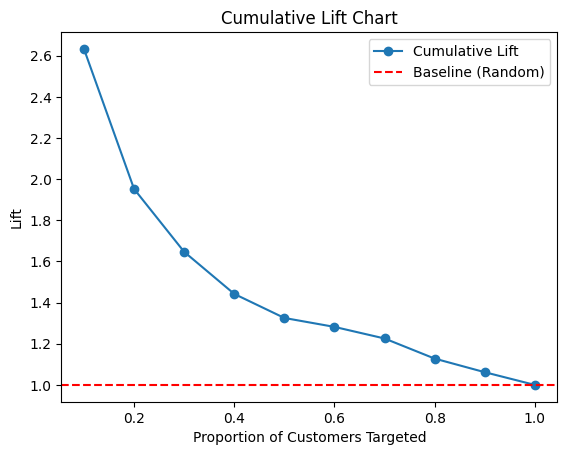

In [ ]:
# Plot cumulative lift chart
plt.plot(grouped["Cumulative Number of Customers"] / grouped["Cumulative Number of Customers"].max(),
         grouped['Lift Score'], marker='o', label="Cumulative Lift")

# Add baseline line (random selection, lift = 1)
plt.axhline(y=1, color='red', linestyle='--', label="Baseline (Random)")

# Set plot title and labels
plt.title("Cumulative Lift Chart")
plt.xlabel("Proportion of Customers Targeted")
plt.ylabel("Lift")
plt.legend()

# Display the plot
plt.show()


# Cumulative Gain Chart

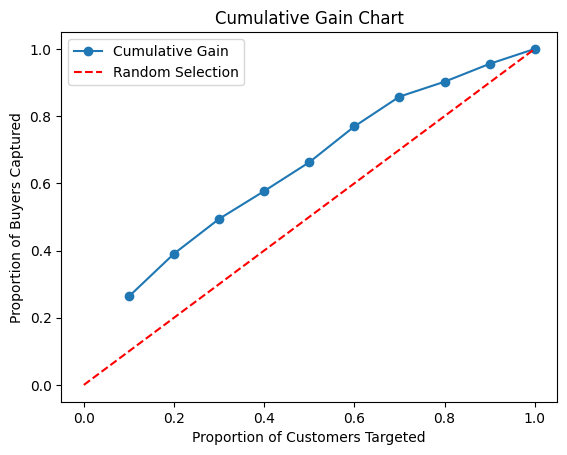

In [ ]:
plt.plot(grouped["Cumulative Number of Customers"] / grouped["Cumulative Number of Customers"].max(),
         grouped['Gain Score'], marker='o',label="Cumulative Gain")

# Add the 45-degree line representing random selection
plt.plot([0, 1], [0, 1], 'r--', label="Random Selection")

# Set plot title and labels
plt.title("Cumulative Gain Chart")
plt.xlabel("Proportion of Customers Targeted")
plt.ylabel("Proportion of Buyers Captured")
plt.legend()
plt.show()